In [ ]:
import zipfile
import os

zip_path = "/content/FINAL_DATASET.zip"  
extract_path = "/content"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [ ]:
os.listdir("/content/FINAL_DATASET")

['Recyclable', 'Organic']

In [ ]:
print("Organic Images:", len(os.listdir("/content/FINAL_DATASET/Organic")))
print("Recyclable Images:", len(os.listdir("/content/FINAL_DATASET/Recyclable")))

Organic Images: 4000
Recyclable Images: 4000


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 8

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/FINAL_DATASET",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "/content/FINAL_DATASET",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 198s 978ms/step - accuracy: 0.7131 - loss: 0.5778 - val_accuracy: 0.8119 - val_loss: 0.4348
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 195s 976ms/step - accuracy: 0.8201 - loss: 0.4281 - val_accuracy: 0.7975 - val_loss: 0.4852
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 193s 967ms/step - accuracy: 0.8355 - loss: 0.3970 - val_accuracy: 0.8213 - val_loss: 0.4109
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 193s 965ms/step - accuracy: 0.8417 - loss: 0.3680 - val_accuracy: 0.8288 - val_loss: 0.4126
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 197s 987ms/step - accuracy: 0.8403 - loss: 0.3642 - val_accuracy: 0.8356 - val_loss: 0.4048
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 194s 972ms/step - accuracy: 0.8651 - loss: 0.3184 - val_accuracy: 0.8231 - val_loss: 0.4488
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 196s 982ms/step - accuracy: 0.8617 - loss: 0.3238 - val_accuracy: 0.8306 - val_loss: 0.4039
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 196s 980ms/step - accuracy: 0.8783 - loss: 0

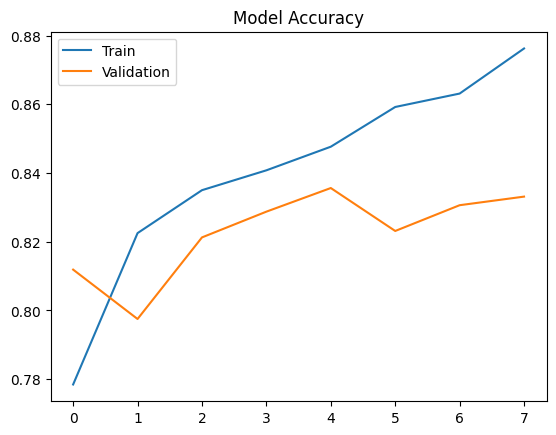

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.show()

In [ ]:
model.save("waste_classifier.keras")

In [ ]:
from google.colab import files
files.download("waste_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>